# TMDB Movie Data Analysis using Pandas and APIs

## Project Overview

This project challenges you to build a movie data analysis pipeline using Python and Pandas.

You will fetch movie-related data from an API, clean and transform the dataset, and implement key performance indicators (KPIs).

This is not a group project, meaning you will design the workflow, structure the analysis, and implement the required calculations independently.

## Project Objectives

   - API Data Extraction: Fetch movie data from a movie database API.

   - Data Cleaning & Transformation: Process and structure the data for analysis.

   - Exploratory Data Analysis (EDA): Perform an initial exploration to understand trends.

   - Advanced Filtering & Ranking: Identify the best and worst movies based on financial and popularity metrics.

   - Franchise & Director Analysis: Assess how franchises and directors perform over time.

   - Visualization & Insights: Present key findings using visualizations.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys


project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import get_settings
from dem02_tmdb_movie.utils import (
     get_movies_dataframe_from_ids,
    clean_movie_df
)

### Step 1: Fetch Movie Data from API

   - Choose a movie database API (e.g., TMDb).

   - Fetch movies with ID:

   - movie_id = [0, 299534, 19995, 140607, 299536, 597, 135397, 420818, 24428, 168259, 99861, 284054, 12445, 181808, 330457, 351286, 109445, 321612, 260513]

   - Store the data as a Pandas DataFrame.

   - NB: Read the API documentation to understand the nature of the data and how it's organized.


In [2]:
# Download movies
MOVIE_IDS = [
    0,
    299534,
    19995,
    140607,
    299536,
    597,
    135397,
    420818,
    24428,
    168259,
    99861,
    284054,
    12445,
    181808,
    330457,
    351286,
    109445,
    321612,
    260513,
]

df, failed = get_movies_dataframe_from_ids(settings=get_settings(), movie_ids=MOVIE_IDS, max_retries=0)

if failed:
    print(f"\nThe following IDs could not be fetched: {failed}")

Fetching Movies:   0%|          | 0/1 [00:00<?, ?it/s]INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/0?append_to_response=credits "HTTP/1.1 404 Not Found"
ERROR:TMDB_Pipeline:Hard error 404 for ID 0. Skipping.
ERROR:TMDB_Pipeline:Final failure for Movie ID 0: Status 404
Fetching Movies: 100%|██████████| 1/1 [00:01<00:00,  1.12s/it]


The following IDs could not be fetched: [0]


In [3]:
df.head()

,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,...,tagline,title,video,vote_average,vote_count,cast,crew,cast_size,crew_size,director
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",356000000.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 878, ...",https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,en,Avengers: Endgame,...,Avenge the fallen.,Avengers: Endgame,False,8.235,27373,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",104,610,Anthony Russo|Joe Russo
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,"{'id': 87096, 'name': 'Avatar Collection', 'po...",237000000.0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",https://www.avatar.com/movies/avatar,19995,tt0499549,en,Avatar,...,Enter the world of Pandora.,Avatar,False,7.600,33620,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",67,996,James Cameron
2,False,/8BTsTfln4jlQrLXUBquXJ0ASQy9.jpg,"{'id': 10, 'name': 'Star Wars Collection', 'po...",245000000.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,en,Star Wars: The Force Awakens,...,Every generation has a story.,Star Wars: The Force Awakens,False,7.250,20351,"[{'adult': False, 'gender': 1, 'id': 1315036, ...","[{'adult': False, 'gender': 2, 'id': 491, 'kno...",99,265,J.J. Abrams
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",300000000.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,en,Avengers: Infinity War,...,Destiny arrives all the same.,Avengers: Infinity War,False,8.234,31610,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",69,737,Anthony Russo|Joe Russo
4,False,/qBChUbS8ksbJoPTfZpogsnxG5tY.jpg,None,200000000.0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",https://www.paramountmovies.com/movies/titanic,597,tt0120338,en,Titanic,...,Nothing on earth could come between them.,Titanic,False,7.903,26890,"[{'adult': False, 'gender': 2, 'id': 6193, 'kn...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",116,264,James Cameron


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  18 non-null     bool   
 1   backdrop_path          18 non-null     str    
 2   belongs_to_collection  16 non-null     object 
 3   budget                 18 non-null     float64
 4   genres                 18 non-null     object 
 5   homepage               18 non-null     str    
 6   id                     18 non-null     int64  
 7   imdb_id                18 non-null     str    
 8   original_language      18 non-null     str    
 9   original_title         18 non-null     str    
 10  overview               18 non-null     str    
 11  popularity             18 non-null     float64
 12  poster_path            18 non-null     str    
 13  production_companies   18 non-null     object 
 14  production_countries   18 non-null     object 
 15  release_date       

In [5]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count,cast_size,crew_size
count,1.800000e+01,18.000000,18.000000,1.800000e+01,18.000000,18.000000,18.000000,18.000000,18.000000
mean,2.137778e+08,192258.444444,18.332089,1.691832e+09,138.055556,7.395111,20816.777778,79.666667,385.833333
std,6.195972e+07,132476.949284,10.054962,5.210623e+08,23.848720,0.516511,8084.809529,30.917347,261.892490
min,1.250000e+08,597.000000,9.681100,1.243226e+09,102.000000,6.532000,10190.000000,20.000000,41.000000
25%,1.625000e+08,102257.000000,11.265025,1.334902e+09,125.250000,7.127500,14150.750000,61.000000,206.750000
50%,2.000000e+08,175033.500000,15.191900,1.484542e+09,135.500000,7.260000,20873.000000,71.500000,275.500000
75%,2.430000e+08,299535.500000,20.343175,1.957196e+09,147.500000,7.827250,26216.000000,104.750000,600.000000
max,3.560000e+08,420818.000000,47.720300,2.923706e+09,194.000000,8.235000,36510.000000,139.000000,996.000000


In [6]:
# Missing %
(
    df
    .isna()
    .mean()
    .mul(100)
    .to_frame(name='missing_pct')
    .sort_values('missing_pct', ascending=False)
)

,missing_pct
belongs_to_collection,11.111111
adult,0.000000
backdrop_path,0.000000
budget,0.000000
genres,0.000000
homepage,0.000000
id,0.000000
imdb_id,0.000000
original_language,0.000000
original_title,0.000000


In [7]:
# Columns with objects or lists
json_cols = [
    'belongs_to_collection',
    'genres',
    'production_countries',
    'production_companies',
    'spoken_languages'
    'crew',
    'cast'
] #ignoring "crew", "cast" too huge. Uncomment to see the data

for col in json_cols:
    if col in df.columns:
        sample_val = df[col].iloc[0]
        print(f"Column: {col} | Type: {type(sample_val)}")
        if isinstance(sample_val, list):
            print(f"Sample Content: {sample_val[:3]}...\n")
        else:
            print(f"Sample Content: {sample_val}\n")


Column: belongs_to_collection | Type: <class 'dict'>
Sample Content: {'id': 86311, 'name': 'The Avengers Collection', 'poster_path': '/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg', 'backdrop_path': '/2UNUv4NJdC36E5myDHACBJ99EwL.jpg'}

Column: genres | Type: <class 'list'>
Sample Content: [{'id': 12, 'name': 'Adventure'}, {'id': 878, 'name': 'Science Fiction'}, {'id': 28, 'name': 'Action'}]...

Column: production_countries | Type: <class 'list'>
Sample Content: [{'iso_3166_1': 'US', 'name': 'United States of America'}]...

Column: production_companies | Type: <class 'list'>
Sample Content: [{'id': 420, 'name': 'Marvel Studios', 'logo_path': '/hUzeosd33nzE5MCNsZxCGEKTXaQ.png', 'origin_country': 'US'}]...

Column: cast | Type: <class 'list'>
Sample Content: [{'adult': False, 'gender': 2, 'id': 3223, 'known_for_department': 'Acting', 'name': 'Robert Downey Jr.', 'original_name': 'Robert Downey Jr.', 'popularity': 9.3107, 'profile_path': '/5qHNjhtjMD4YWH3UP0rm4tKwxCL.jpg', 'cast_id': 493, 'character': 

In [8]:
#  Categorical Distribution
(
    df[['status', 'original_language']]
    .melt(var_name='column', value_name='value')
    .value_counts()
    .to_frame(name='count')
)

,,count
column,value,
status,Released,18
original_language,en,18


In [9]:
# checking zeros financial columns
(
    (df[['budget', 'revenue', 'runtime']] == 0)
    .sum()
    .to_frame(name='count_of_zeros')
)

,count_of_zeros
budget,0
revenue,0
runtime,0


## Step 2: Data Cleaning and Preprocessing

### Data Preparation & Cleaning

   1. Drop irrelevant columns: ['adult', 'imdb_id', 'original_title', 'video', 'homepage'].

   2. Evaluate JSON-like columns (['belongs_to_collection', 'genres', 'production_countries', 'production_companies', 'spoken_languages']).

   3. Extract and clean key data points:

        - Collection name (belongs_to_collection)

        - Genre names (genres → separate multiple genres with "|").

        - Spoken languages (spoken_languages → separate with "|").

        - Production countries (production_countries → separate with "|").

        - Production companies (production_companies → separate with "|").

   4. Inspect extracted columns using value_counts() to identify anomalies.

Handling Missing & Incorrect Data


   5. Convert column datatypes:

        'budget', 'id', 'popularity' → Numeric (set invalid values to NaN).
        'release_date' → Convert to datetime.
        etc

   6. Replace unrealistic values:

        Budget/Revenue/Runtime $= 0$ → Replace with NaN or infer from similar movies.
        Convert 'budget' and 'revenue' to million USD.
        Movies with vote_count = 0 → Analyze their vote_average and adjust accordingly.
        'overview' and 'tagline' → Replace known placeholders (e.g., 'No Data') with NaN.

   7. Remove duplicates and drop rows with unknown 'id' or 'title'.

   8. Keep only rows where at least 10 columns have non-NaN values.

   9. Filter to include only 'Released' movies, then drop 'status'.

**Reorder & Finalize DataFrame**

   10. Reorder columns:

   ```
    ['id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection', 'original_language',
        'budget_musd', 'revenue_musd', 'production_companies', 'production_countries', 'vote_count', 'vote_average',
        'popularity', 'runtime', 'overview', 'spoken_languages', 'poster_path', 'cast', 'cast_size', 'director', 'crew_size']
   ```
   11. Reset index.


In [10]:
# Define the columns to drop
cols_to_drop = ['adult', 'imdb_id', 'original_title', 'video', 'homepage']

# Define the final column order as per instructions
final_column_order = [
    'id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection',
    'original_language', 'budget_musd', 'revenue_musd', 'production_companies',
    'production_countries', 'vote_count', 'vote_average', 'popularity', 'runtime',
    'overview', 'spoken_languages', 'poster_path', 'cast', 'cast_size', 'director', 'crew_size'
]

# Cleaning pipeline using chaining
df_cleaned  = clean_movie_df(df, cols_to_drop=cols_to_drop, final_column_order=final_column_order)

df_cleaned.head(10)

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,8.235,18.7720,181.0,After the devastating events of Avengers: Infi...,English|Japanese|Xhosa,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Anthony Russo|Joe Russo,610
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,7.600,29.8293,162.0,"In the 22nd century, a paraplegic Marine is di...",English|Spanish,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,7.250,12.0194,136.0,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,265
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,8.234,30.4098,149.0,As the Avengers and their allies have continue...,English|Xhosa,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,737
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,Paramount Pictures|20th Century Fox|Lightstorm...,...,7.903,29.1545,194.0,101-year-old Rose DeWitt Bukater tells the sto...,English|French|German|Swedish|Italian|Russian,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,264
5,135397,Jurassic World,The park is open.,2015-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Universal Pictures|Legend...,...,6.699,11.9662,124.0,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,428
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Drama|Family|Animation,The Lion King (Reboot) Collection,en,260.0,1662.020819,Walt Disney Pictures|Fairview Entertainment,...,7.097,10.6322,118.0,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,52
7,24428,The Avengers,Some assembly required.,2012-04-25,Science Fiction|Action|Adventure,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,7.968,47.7203,143.0,When an unexpected enemy emerges and threatens...,English|Hindi|Russian,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,642
8,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,Original Film|One Race|Universal Pictures,...,7.219,11.1067,139.0,Deckard Shaw seeks revenge against Dominic Tor...,Arabic|English|Spanish|Thai,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,49,James Wan,230
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,7.270,16.9180,141.0,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,74,Joss Whedon,655


## Step 3: KPI Implementation & Analysis

### Identify the Best/Worst Performing Movies

   1. Filter and rank movies based on:

        - Highest Revenue

        - Highest Budget

        - Highest Profit (Revenue - Budget)

        - Lowest Profit (Revenue - Budget)

        - Highest ROI (Revenue / Budget) (only movies with Budget $\ge 10M$)

        - Lowest ROI (only movies with Budget $\ge 10M$)

        - Most Voted Movies

        - Highest Rated Movies (only movies with $\ge 10$ votes)

        - Lowest Rated Movies (only movies with $\ge 10$ votes)

        - Most Popular Movies

   - Define a User-Defined Function (UDF) to streamline ranking operations.

Advanced Movie Filtering & Search Queries

   3. Filter the dataset for specific queries:

        - Search 1: Find the best-rated Science Fiction Action movies starring Bruce Willis (sorted by Rating - highest to lowest).
        - Search 2: Find movies starring Uma Thurman, directed by Quentin Tarantino (sorted by runtime - shortest to longest).

#### Franchise vs. Standalone Movie Performance

   4. Compare movie franchises (belongs_to_collection) vs. standalone movies in terms of:

        - Mean Revenue
        - Median ROI
        - Mean Budget Raised
        - Mean Popularity
        - Mean Rating

#### Most Successful Franchises & Directors

   5. Find the Most Successful Movie Franchises based on:

        - Total number of movies in franchise
        - Total & Mean Budget
        - Total & Mean Revenue
        - Mean Rating

   6. Find the Most Successful Directors based on:

        - Total Number of Movies Directed
        - Total Revenue
        - Mean Rating


In [11]:
# Add Profit and ROI columns to our cleaned dataframe
df_final = df_cleaned.assign(
    profit_musd =  df_cleaned['revenue_musd'] - df_cleaned['budget_musd'],
    roi = df_cleaned['revenue_musd'] / df_cleaned['budget_musd']
)

df_final

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181.0,After the devastating events of Avengers: Infi...,English|Japanese|Xhosa,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Anthony Russo|Joe Russo,610,2443.439100,7.863593
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,162.0,"In the 22nd century, a paraplegic Marine is di...",English|Spanish,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996,2686.706026,12.336312
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,136.0,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,265,1823.223624,8.441729
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,149.0,As the Avengers and their allies have continue...,English|Xhosa,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,737,1752.415039,6.841383
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,Paramount Pictures|20th Century Fox|Lightstorm...,...,194.0,101-year-old Rose DeWitt Bukater tells the sto...,English|French|German|Swedish|Italian|Russian,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,264,2064.162353,11.320812
5,135397,Jurassic World,The park is open.,2015-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Universal Pictures|Legend...,...,124.0,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,428,1521.537444,11.143583
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Drama|Family|Animation,The Lion King (Reboot) Collection,en,260.0,1662.020819,Walt Disney Pictures|Fairview Entertainment,...,118.0,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,52,1402.020819,6.392388
7,24428,The Avengers,Some assembly required.,2012-04-25,Science Fiction|Action|Adventure,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,143.0,When an unexpected enemy emerges and threatens...,English|Hindi|Russian,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,642,1298.815515,6.903707
8,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,Original Film|One Race|Universal Pictures,...,139.0,Deckard Shaw seeks revenge against Dominic Tor...,Arabic|English|Spanish|Thai,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,49,James Wan,230,1325.400000,7.975789
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,141.0,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,74,Joss Whedon,655,1170.403694,5.980441


In [12]:
def rank_movies(movie_df, column, n=5, ascending=False, min_votes=0, min_budget=0):
    """
    Ranks movies based on a specific column with optional quality filters.
    """
    return (
        movie_df
        .query(f"vote_count >= {min_votes} and budget_musd >= {min_budget}")
        .sort_values(by=column, ascending=ascending)
        [['title', column, 'vote_count', 'budget_musd', 'revenue_musd']]
        .head(n)
    )

In [13]:
import pandas as pd

def df_to_typst(df: pd.DataFrame, caption: str = "", columns_spec: str = None) -> str:
    """
    Converts a Pandas DataFrame into a Typst table string.

    :param df: The DataFrame to convert.
    :param caption: Optional figure caption.
    :param columns_spec: Typst column specification (e.g., "(2fr, 1fr, 1fr)").
                         If None, it defaults to equal fractional columns.
    """
    # 1. Default column spec if not provided (equal width)
    if not columns_spec:
        columns_spec = f"({', '.join(['1fr'] * len(df.columns))})"

    # 2. Start the table string
    typst_lines = ["#figure(", f"  table(", f"    columns: {columns_spec},", f"    inset: 10pt,",
                   f"    align: horizon,", f"    fill: (x, y) => if y == 0 {{ gray.lighten(60%) }},"]

    # 3. Add Headers (Bolded)
    headers = ", ".join([f"[* {col.replace('_', ' ').title()} *]" for col in df.columns])
    typst_lines.append(f"    {headers},")

    # 4. Add Rows
    for _, row in df.iterrows():
        row_vals = []
        for val in row:
            # Format numbers to 2 decimal places, handle NaNs
            if pd.isna(val):
                row_vals.append("[---]")
            elif isinstance(val, (int, float)):
                # If it looks like a large currency/ROI value
                row_vals.append(f"[{val:,.2f}]")
            else:
                row_vals.append(f"[{str(val)}]")

        typst_lines.append(f"    {', '.join(row_vals)},")

    typst_lines.append("  ),")
    if caption:
        typst_lines.append(f"  caption: [{caption}],")
    typst_lines.append(")")

    return "\n".join(typst_lines)


In [14]:
# 1. Highest Revenue
top_revenue = rank_movies(df_final, 'revenue_musd')
top_revenue

,title,revenue_musd,vote_count,budget_musd,revenue_musd
1,Avatar,2923.706026,33620,237.0,2923.706026
0,Avengers: Endgame,2799.439100,27373,356.0,2799.439100
4,Titanic,2264.162353,26890,200.0,2264.162353
2,Star Wars: The Force Awakens,2068.223624,20351,245.0,2068.223624
3,Avengers: Infinity War,2052.415039,31610,300.0,2052.415039


In [15]:
print(df_to_typst(top_revenue, "Top 5 Highest Revenue Movies", "(2fr, 1fr, 1fr, 1fr, 1fr)"))

#figure(
  table(
    columns: (2fr, 1fr, 1fr, 1fr, 1fr),
    inset: 10pt,
    align: horizon,
    fill: (x, y) => if y == 0 { gray.lighten(60%) },
    [* Title *], [* Revenue Musd *], [* Vote Count *], [* Budget Musd *], [* Revenue Musd *],
    [Avatar], [2,923.71], [33,620.00], [237.00], [2,923.71],
    [Avengers: Endgame], [2,799.44], [27,373.00], [356.00], [2,799.44],
    [Titanic], [2,264.16], [26,890.00], [200.00], [2,264.16],
    [Star Wars: The Force Awakens], [2,068.22], [20,351.00], [245.00], [2,068.22],
    [Avengers: Infinity War], [2,052.42], [31,610.00], [300.00], [2,052.42],
  ),
  caption: [Top 5 Highest Revenue Movies],
)


In [16]:
# 2. Highest Budget
top_budget = rank_movies(df_final, 'budget_musd')
top_budget

,title,budget_musd,vote_count,budget_musd,revenue_musd
0,Avengers: Endgame,356.0,27373,356.0,2799.439100
3,Avengers: Infinity War,300.0,31610,300.0,2052.415039
12,Star Wars: The Last Jedi,300.0,16155,300.0,1332.698830
6,The Lion King,260.0,10669,260.0,1662.020819
2,Star Wars: The Force Awakens,245.0,20351,245.0,2068.223624


In [17]:
# 3. Highest Profit
top_profit = rank_movies(df_final, 'profit_musd')
top_profit

,title,profit_musd,vote_count,budget_musd,revenue_musd
1,Avatar,2686.706026,33620,237.0,2923.706026
0,Avengers: Endgame,2443.439100,27373,356.0,2799.439100
4,Titanic,2064.162353,26890,200.0,2264.162353
2,Star Wars: The Force Awakens,1823.223624,20351,245.0,2068.223624
3,Avengers: Infinity War,1752.415039,31610,300.0,2052.415039


In [18]:
# 4. Lowest Profit (Worst Financial Performance)
worst_profit = rank_movies(df_final, 'profit_musd', ascending=True)
worst_profit

,title,profit_musd,vote_count,budget_musd,revenue_musd
12,Star Wars: The Last Jedi,1032.698830,16155,300.0,1332.698830
17,Incredibles 2,1043.225667,13555,200.0,1243.225667
16,Beauty and the Beast,1106.115964,15938,160.0,1266.115964
15,Frozen,1124.219009,17418,150.0,1274.219009
14,Jurassic World: Fallen Kingdom,1140.469037,12617,170.0,1310.469037


In [19]:
# 5. Highest ROI (Only movies with Budget >= 10M)
top_roi = rank_movies(df_final, 'roi', min_budget=10)
top_roi

,title,roi,vote_count,budget_musd,revenue_musd
1,Avatar,12.336312,33620,237.0,2923.706026
4,Titanic,11.320812,26890,200.0,2264.162353
5,Jurassic World,11.143583,21395,150.0,1671.537444
11,Harry Potter and the Deathly Hallows: Part 2,10.732090,21769,125.0,1341.511219
13,Frozen II,9.691223,10190,150.0,1453.683476


In [20]:
# 6. Lowest ROI (Only movies with Budget >= 10M)
worst_roi = rank_movies(df_final, 'roi', min_budget=10, ascending=True)
worst_roi

,title,roi,vote_count,budget_musd,revenue_musd
12,Star Wars: The Last Jedi,4.442329,16155,300.0,1332.698830
9,Avengers: Age of Ultron,5.980441,24194,235.0,1405.403694
17,Incredibles 2,6.216128,13555,200.0,1243.225667
6,The Lion King,6.392388,10669,260.0,1662.020819
10,Black Panther,6.749630,23265,200.0,1349.926083


In [21]:
# 7. Most Voted
most_voted = rank_movies(df_final, 'vote_count')
most_voted

,title,vote_count,vote_count,budget_musd,revenue_musd
7,The Avengers,36510,36510,220.0,1518.815515
1,Avatar,33620,33620,237.0,2923.706026
3,Avengers: Infinity War,31610,31610,300.0,2052.415039
0,Avengers: Endgame,27373,27373,356.0,2799.439100
4,Titanic,26890,26890,200.0,2264.162353


In [22]:
# 8. Highest Rated (Only movies with >= 10 votes)
top_rated = rank_movies(df_final, 'vote_average', min_votes=10)
top_rated

,title,vote_average,vote_count,budget_musd,revenue_musd
0,Avengers: Endgame,8.235,27373,356.0,2799.439100
3,Avengers: Infinity War,8.234,31610,300.0,2052.415039
11,Harry Potter and the Deathly Hallows: Part 2,8.081,21769,125.0,1341.511219
7,The Avengers,7.968,36510,220.0,1518.815515
4,Titanic,7.903,26890,200.0,2264.162353


In [23]:
# 9. Lowest Rated (Only movies with >= 10 votes)
worst_rated = rank_movies(df_final, 'vote_average', min_votes=10, ascending=True)
worst_rated

,title,vote_average,vote_count,budget_musd,revenue_musd
14,Jurassic World: Fallen Kingdom,6.532,12617,170.0,1310.469037
5,Jurassic World,6.699,21395,150.0,1671.537444
12,Star Wars: The Last Jedi,6.757,16155,300.0,1332.698830
16,Beauty and the Beast,6.968,15938,160.0,1266.115964
6,The Lion King,7.097,10669,260.0,1662.020819


In [22]:
# 10. Most Popular
most_popular = rank_movies(df_final, 'popularity')
most_popular

,title,popularity,vote_count,budget_musd,revenue_musd
7,The Avengers,47.7203,36510,220.0,1518.815515
3,Avengers: Infinity War,30.4098,31610,300.0,2052.415039
1,Avatar,29.8293,33620,237.0,2923.706026
4,Titanic,29.1545,26890,200.0,2264.162353
12,Star Wars: The Last Jedi,20.8669,16155,300.0,1332.698830


In [24]:
# Search 1: Find the best-rated Science Fiction Action movies starring Bruce Willis (sorted by Rating - highest to lowest).
search_bruce = (
    df_final
    .loc[
        df_final['cast'].str.contains("Bruce Willis", case=False, na=False)  &
        df_final['genres'].str.contains("Action", case=False, na=False) &
        df_final['genres'].str.contains("Science Fiction", case=False, na=False)
    ]
    .sort_values(by='vote_average', ascending=False)
)

rank_movies(search_bruce, column='vote_average')

,title,vote_average,vote_count,budget_musd,revenue_musd


In [25]:
# Search 2: Find movies starring Uma Thurman, directed by Quentin Tarantino (sorted by runtime - shortest to longest).
search_quentin = (
    df_final
    .loc[
        df_final['director'].str.contains("Quentin Tarantino", case=False, na=False) &
        df_final['cast'].str.contains("Uma Thurman", case=False, na=False)
    ]
    .sort_values(by='runtime', ascending=True)
)
rank_movies(search_quentin, column='runtime', ascending=True)

,title,runtime,vote_count,budget_musd,revenue_musd


In [25]:
# Compare movie franchises (belongs_to_collection) vs. standalone movies
franchise_comparison = (
    df_final
    .assign(status =  np.where(df_final['belongs_to_collection'].isna(), "Standalone", "Franchise"))
    .groupby('status')
    .agg(
        mean_revenue = ('revenue_musd', 'mean'),
        median_roi = ('roi', 'median'),
        mean_budget = ('budget_musd', 'mean'),
        mean_popularity = ('popularity', 'mean'),
        mean_rating = ('vote_average', 'mean')
    )
)

franchise_comparison

,mean_revenue,median_roi,mean_budget,mean_popularity,mean_rating
status,,,,,
Franchise,1682.668411,7.786117,218.0,18.067694,7.390062
Standalone,1765.139159,9.617018,180.0,20.447250,7.435500


In [26]:
#  Find the Most Successful Movie Franchises based on:
top_franchises = (
    df_final
    .dropna(subset=['belongs_to_collection'])
    .groupby('belongs_to_collection')
    .agg(
        movie_count = ('id', 'count'),
        total_budget = ('budget_musd', 'sum'),
        mean_budget = ('budget_musd', 'mean'),
        total_revenue = ('revenue_musd', 'sum'),
        mean_revenue = ('revenue_musd', 'mean'),
        mean_rating = ('vote_average', 'mean')
    )
    .sort_values(by='movie_count', ascending=False)
    .head(5)
)

top_franchises

,movie_count,total_budget,mean_budget,total_revenue,mean_revenue,mean_rating
belongs_to_collection,,,,,,
The Avengers Collection,4,1111.0,277.75,7776.073348,1944.018337,7.92675
Frozen Collection,2,300.0,150.00,2727.902485,1363.951242,7.24150
Star Wars Collection,2,545.0,272.50,3400.922454,1700.461227,7.00350
Jurassic Park Collection,2,320.0,160.00,2982.006481,1491.003241,6.61550
Black Panther Collection,1,200.0,200.00,1349.926083,1349.926083,7.36200


In [27]:
# Find the Most Successful Directors based on:
top_directors = (
    df_final
    .dropna(subset=['director'])
    .assign(director = df_final['director'].str.split('|'))
    .explode('director')
    .groupby('director')
    .agg(
        movie_count = ('id', 'count'),
        total_revenue = ('revenue_musd', 'sum'),
        avg_rating = ('vote_average', 'mean')
    )
    .sort_values(by='total_revenue', ascending=False)
    .head(5)
)
top_directors

,movie_count,total_revenue,avg_rating
director,,,
James Cameron,2,5187.868379,7.7515
Anthony Russo,2,4851.854139,8.2345
Joe Russo,2,4851.854139,8.2345
Joss Whedon,2,2924.219209,7.6190
Jennifer Lee,2,2727.902485,7.2415


## Step 4: Data Visualization

### Use Pandas, Matplotlib to visualize:

   - Revenue vs. Budget Trends

   - ROI Distribution by Genre

   - Popularity vs. Rating

   - Yearly Trends in Box Office Performance

   - Comparison of Franchise vs. Standalone Success


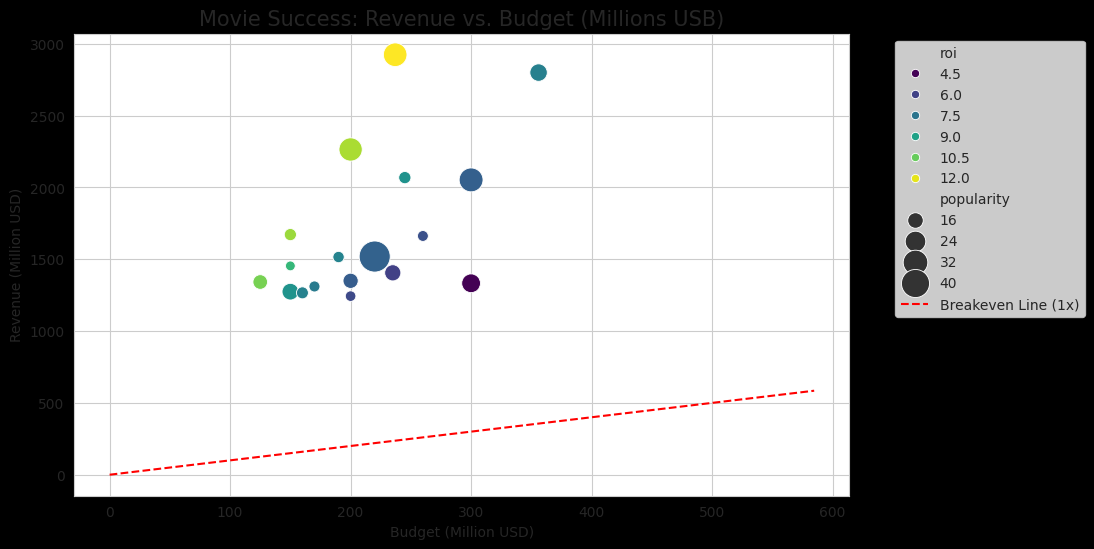

In [28]:
# Revenue vs. Budget Trends
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Scatter plot
sns.scatterplot(
    data=df_final,
    x='budget_musd',
    y='revenue_musd',
    size='popularity',
    hue='roi',
    palette='viridis',
    sizes=(50, 500)
)

# Add a diagonal line for breakeven (Revenue = Budget)
max_val = max(df_final['revenue_musd'].max(), df_final['budget_musd'].max())
plt.plot([0, max_val/5], [0, max_val/5], color='red', linestyle='--', label='Breakeven Line (1x)')

plt.title('Movie Success: Revenue vs. Budget (Millions USB)', fontsize=15)
plt.xlabel('Budget (Million USD)')
plt.ylabel('Revenue (Million USD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

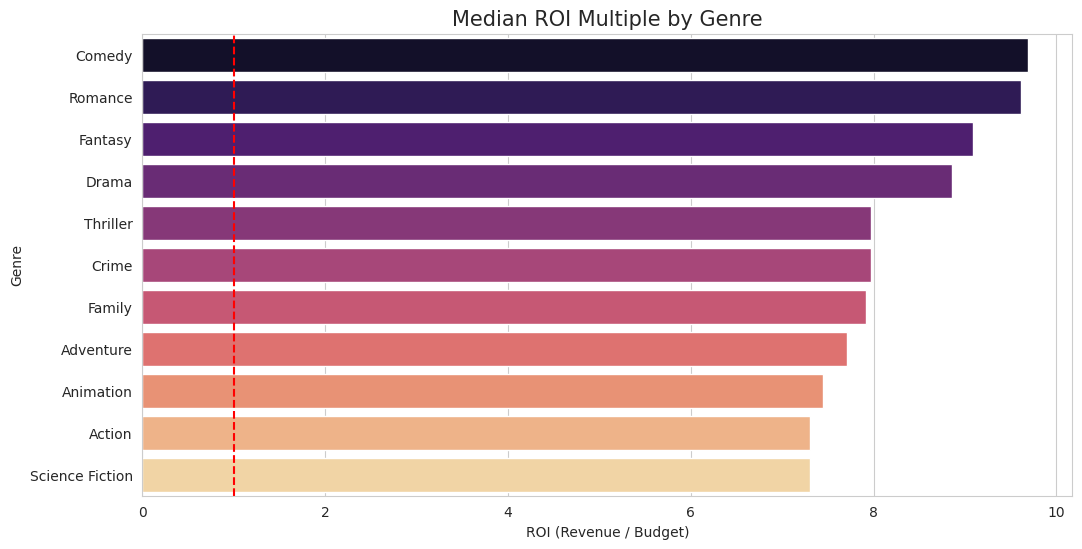

In [29]:
# ROI Distribution by Genre
genre_roi = (
    df_final[['id', 'genres', 'revenue_musd', 'roi', 'budget_musd']]
    .dropna(subset=['genres'])
    .assign(genres = df_final['genres'].str.split('|'))
    .explode('genres')
    .groupby('genres')["roi"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=genre_roi.values,
    y=genre_roi.index,
    hue=genre_roi.index,
    palette='magma',
    legend=False
)
plt.title('Median ROI Multiple by Genre', fontsize=15)
plt.xlabel('ROI (Revenue / Budget)')
plt.ylabel('Genre')
plt.axvline(1, color='red', linestyle='--', label='Breakeven (1x)')
plt.show()

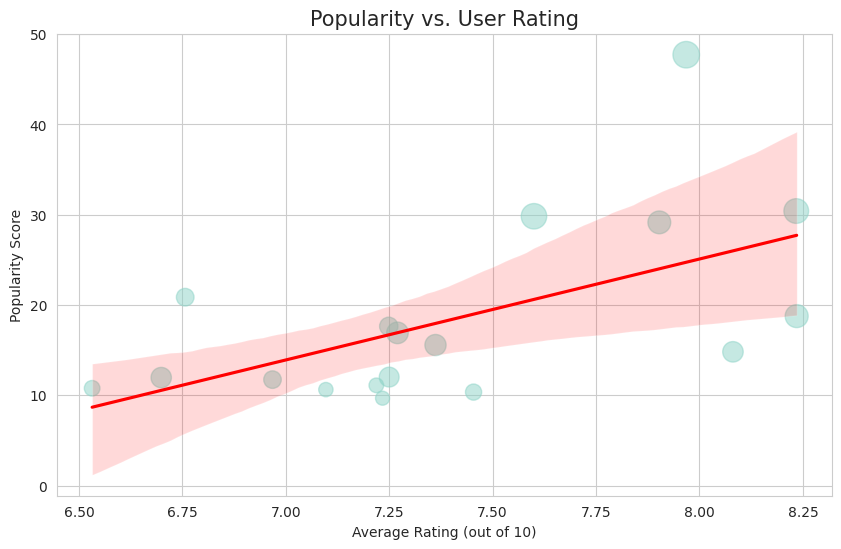

In [30]:
# Popularity vs. Rating
plt.figure(figsize=(10, 6))
sns.regplot(data=df_final, x='vote_average', y='popularity',
            scatter_kws={'s':df_final['vote_count']/100, 'alpha':0.5}, # Size based on vote count
            line_kws={'color':'red'})

plt.title('Popularity vs. User Rating', fontsize=15)
plt.xlabel('Average Rating (out of 10)')
plt.ylabel('Popularity Score')
plt.show()

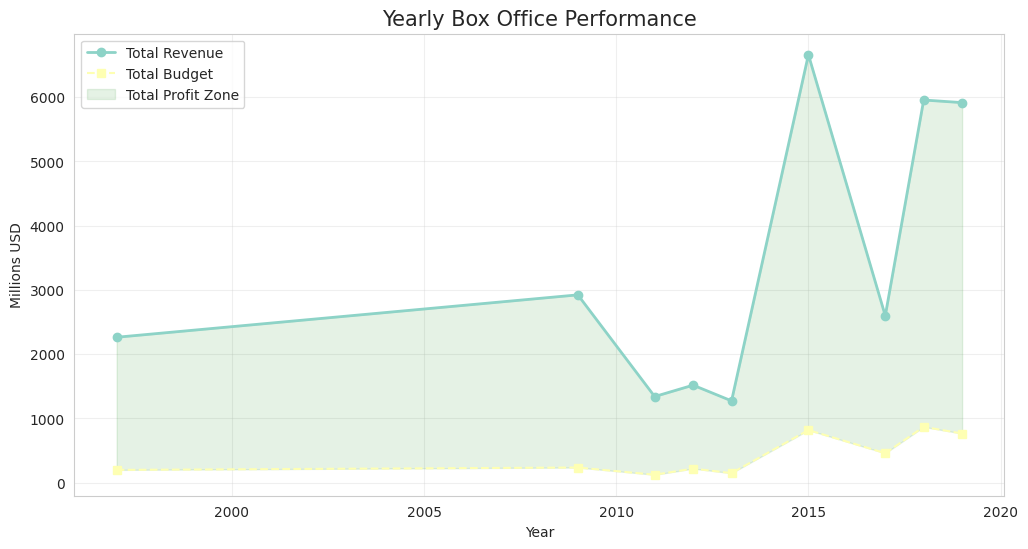

In [31]:
# Yearly Trends in Box Office Performance
# Extract Year and group
yearly_trends = (
    df_final
    .assign(year = df_final['release_date'].dt.year)
    .groupby('year')
    .agg({'revenue_musd': 'sum', 'budget_musd': 'sum'})
)

plt.figure(figsize=(12, 6))
plt.plot(yearly_trends.index, yearly_trends['revenue_musd'], marker='o', label='Total Revenue', linewidth=2)
plt.plot(yearly_trends.index, yearly_trends['budget_musd'], marker='s', label='Total Budget', linestyle='--')

plt.fill_between(
    yearly_trends.index,
     yearly_trends['budget_musd'],
     yearly_trends['revenue_musd'],
     color='green',
     alpha=0.1,
     label='Total Profit Zone'
)

plt.title('Yearly Box Office Performance', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Millions USD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

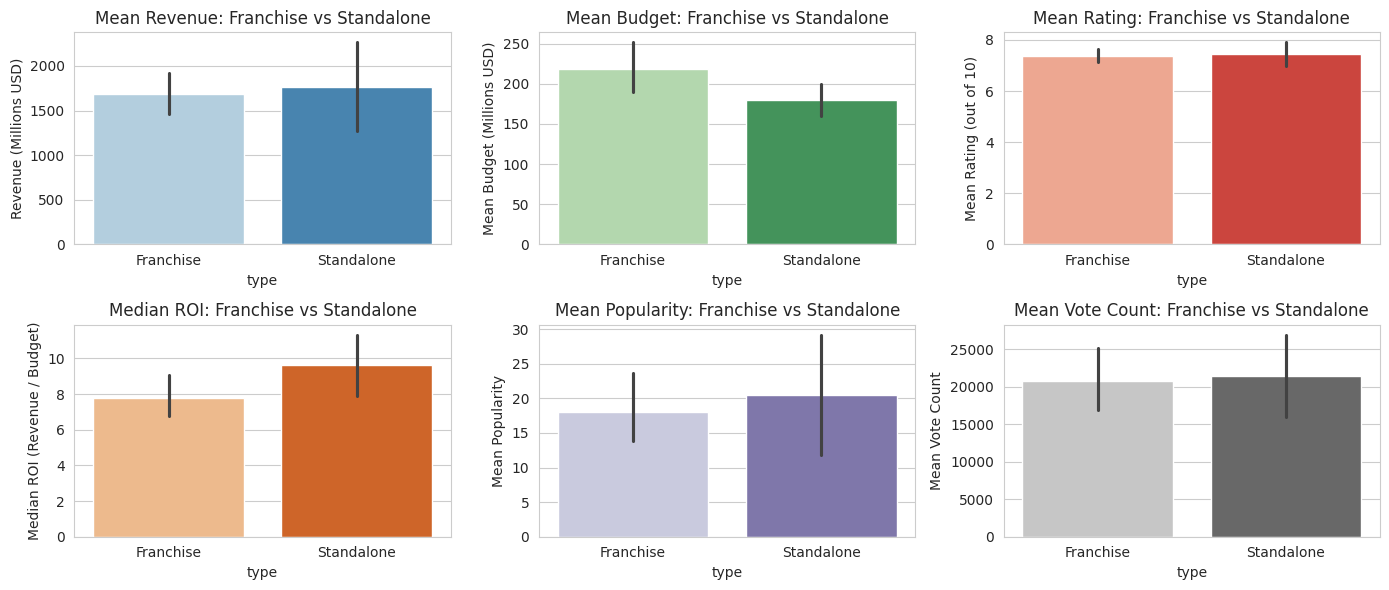

In [32]:
# Comparison of Franchise vs. Standalone Success
df_viz = (
    df_final
    .assign(type = np.where(df_final['belongs_to_collection'].isna(), "Standalone", "Franchise"))
)

fig, ax = plt.subplots(2, 3, figsize=(14, 6))

comp_plots = [
    {
        "y": "revenue_musd",
        "y_label": "Revenue (Millions USD)",
        "title": "Mean Revenue: Franchise vs Standalone",
        "palette": "Blues",
        "estimator": np.mean,
        "position": (0, 0)
    },
    {
        "y": "roi",
        "y_label": "Median ROI (Revenue / Budget)",
        "title": "Median ROI: Franchise vs Standalone",
        "palette": "Oranges",
        "estimator": np.median,
        "position": (1, 0)
    },
    {
        "y": "budget_musd",
        "y_label": "Mean Budget (Millions USD)",
        "title": "Mean Budget: Franchise vs Standalone",
        "palette": "Greens",
        "estimator": np.mean,
        "position": (0, 1)
    },
    {
        "y": "popularity",
        "y_label": "Mean Popularity",
        "title": "Mean Popularity: Franchise vs Standalone",
        "palette": "Purples",
        "estimator": np.mean,
        "position": (1, 1)
    },
    {
        "y": "vote_average",
        "y_label": "Mean Rating (out of 10)",
        "title": "Mean Rating: Franchise vs Standalone",
        "palette": "Reds",
        "estimator": np.mean,
        "position": (0, 2)
    },
    {
        "y": "vote_count",
        "y_label": "Mean Vote Count",
        "title": "Mean Vote Count: Franchise vs Standalone",
        "palette": "Greys",
        "estimator": np.mean,
        "position": (1, 2)
    }

]

for comp_plot in comp_plots:
    sns.barplot(
        data=df_viz,
        x='type',
        y=comp_plot['y'],
        estimator=comp_plot['estimator'],
        hue='type',
        ax=ax[comp_plot['position'][0], comp_plot['position'][1]],
        palette=comp_plot['palette'],
        legend=False
    )

    ax[comp_plot['position'][0], comp_plot['position'][1]].set_title(comp_plot['title'])
    ax[comp_plot['position'][0], comp_plot['position'][1]].set_ylabel(comp_plot['y_label'])


plt.tight_layout()
plt.show()